In [19]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning'

import numpy as np
import scipy.sparse
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

In [20]:
# load preprocessed data
X_train = scipy.sparse.load_npz('../data_processed/X_train.npz')
X_val = scipy.sparse.load_npz('../data_processed/X_val.npz')
X_test = scipy.sparse.load_npz('../data_processed/X_test.npz')
y_train = np.load('../data_processed/y_train.npy')
y_val = np.load('../data_processed/y_val.npy')
y_test = np.load('../data_processed/y_test.npy')

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

label_names = list(le.classes_)
print(f"train: {X_train.shape}, classes: {Counter(y_train)}")
print(f"val: {X_val.shape}")
print(f"test: {X_test.shape}")
print(f"labels: {label_names}")

train: (176638, 3004), classes: Counter({np.int64(0): 88319, np.int64(1): 88319})
val: (13064, 3004)
test: (26128, 3004)
labels: [np.str_('Doctor Consultation'), np.str_('OTC Drug')]


In [21]:
# evaluation function
def evaluate(name, model, X_test, y_test, label_names):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    report = classification_report(y_test, y_pred,
                                   target_names=label_names,
                                   output_dict=True)

    # safety metrics
    doctor_recall = report['Doctor Consultation']['recall']
    otc_precision = report['OTC Drug']['precision']
    otc_recall = report['OTC Drug']['recall']

    auc = None
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        except Exception:
            pass

    print(f"\n{name}")
    print(f"accuracy: {acc:.4f}")
    print(f"weighted f1: {weighted_f1:.4f} (primary)")
    print(f"macro f1: {macro_f1:.4f}")
    print(f"doctor recall: {doctor_recall:.4f}")
    print(f"otc precision: {otc_precision:.4f}")
    print(f"otc recall: {otc_recall:.4f}")
    if auc:
        print(f"auc-roc: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_names))

    return {
        'name': name,
        'model': model,
        'accuracy': acc,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
        'doctor_recall': doctor_recall,
        'otc_precision': otc_precision,
        'otc_recall': otc_recall,
        'auc': auc,
        'y_pred': y_pred,
    }

In [22]:
# define models
lr = LogisticRegression(max_iter=1000, solver='saga', random_state=42)

# multinomial nb for tfidf sparse features
nb = MultinomialNB(alpha=0.1)

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.3,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

# stacking ensemble - base predictions fed into lr meta learner
stack_traditional = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, solver='saga', random_state=42)),
        ('nb', MultinomialNB(alpha=0.1)),
        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05,
                               eval_metric='logloss', random_state=42, n_jobs=-1))
    ],
    final_estimator=LogisticRegression(max_iter=500, solver='saga', random_state=42),
    cv=5, n_jobs=-1
)

# soft voting - average predicted probabilities across models
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, solver='saga', random_state=42)),
        ('nb', MultinomialNB(alpha=0.1)),
        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05,
                               eval_metric='logloss', random_state=42, n_jobs=-1))
    ],
    voting='soft', weights=[2, 1, 3], n_jobs=-1
)

mlp_pipeline = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.001, batch_size=512,
        max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42, verbose=False
    ))
])

# mlp+xgb stacking
stack_deep = StackingClassifier(
    estimators=[
        ('mlp', mlp_pipeline),
        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05,
                               eval_metric='logloss', random_state=42, n_jobs=-1))
    ],
    final_estimator=LogisticRegression(max_iter=500, solver='saga'),
    cv=5, n_jobs=-1
)

models = {
    'Logistic Regression': lr,
    'Multinomial Naive Bayes': nb,
    'XGBoost': xgb,
    'Stacking LR+NB+XGB': stack_traditional,
    'Soft Voting LR+NB+XGB': voting,
    'Stacking MLP+XGB': stack_deep,
}

print(f"{len(models)} models defined")

6 models defined


In [23]:
# Train all models and evaluate on test set
results = {}

for name, model in models.items():
    print(f"\nStarting training for: {name}")

    start = time.time()
    model.fit(X_train, y_train)

    elapsed = time.time() - start

    print(f"Finished training {name}")
    print(f"Training time: {int(elapsed // 60)} minutes {int(elapsed % 60)} seconds")

    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"Validation accuracy: {val_acc:.4f}")

    print("Evaluating on test set")
    results[name] = evaluate(name, model, X_test, y_test, label_names)
    results[name]['train_time'] = elapsed

    fname = name.lower().replace(' ', '_').replace('+', '_')
    with open(f'../models/{fname}.pkl', 'wb') as file:
        pickle.dump(model, file)

    print(f"Model saved to: ../models/{fname}.pkl")
    print("\n")


Starting training for: Logistic Regression
Finished training Logistic Regression
Training time: 0 minutes 3 seconds
Validation accuracy: 0.9444
Evaluating on test set

Logistic Regression
accuracy: 0.9474
weighted f1: 0.9579 (primary)
macro f1: 0.7647
doctor recall: 0.9467
otc precision: 0.3912
otc recall: 0.9686
auc-roc: 0.9876
                     precision    recall  f1-score   support

Doctor Consultation       1.00      0.95      0.97     25235
           OTC Drug       0.39      0.97      0.56       893

           accuracy                           0.95     26128
          macro avg       0.70      0.96      0.76     26128
       weighted avg       0.98      0.95      0.96     26128

Model saved to: ../models/logistic_regression.pkl



Starting training for: Multinomial Naive Bayes
Finished training Multinomial Naive Bayes
Training time: 0 minutes 0 seconds
Validation accuracy: 0.8821
Evaluating on test set

Multinomial Naive Bayes
accuracy: 0.8848
weighted f1: 0.9169 (primary)

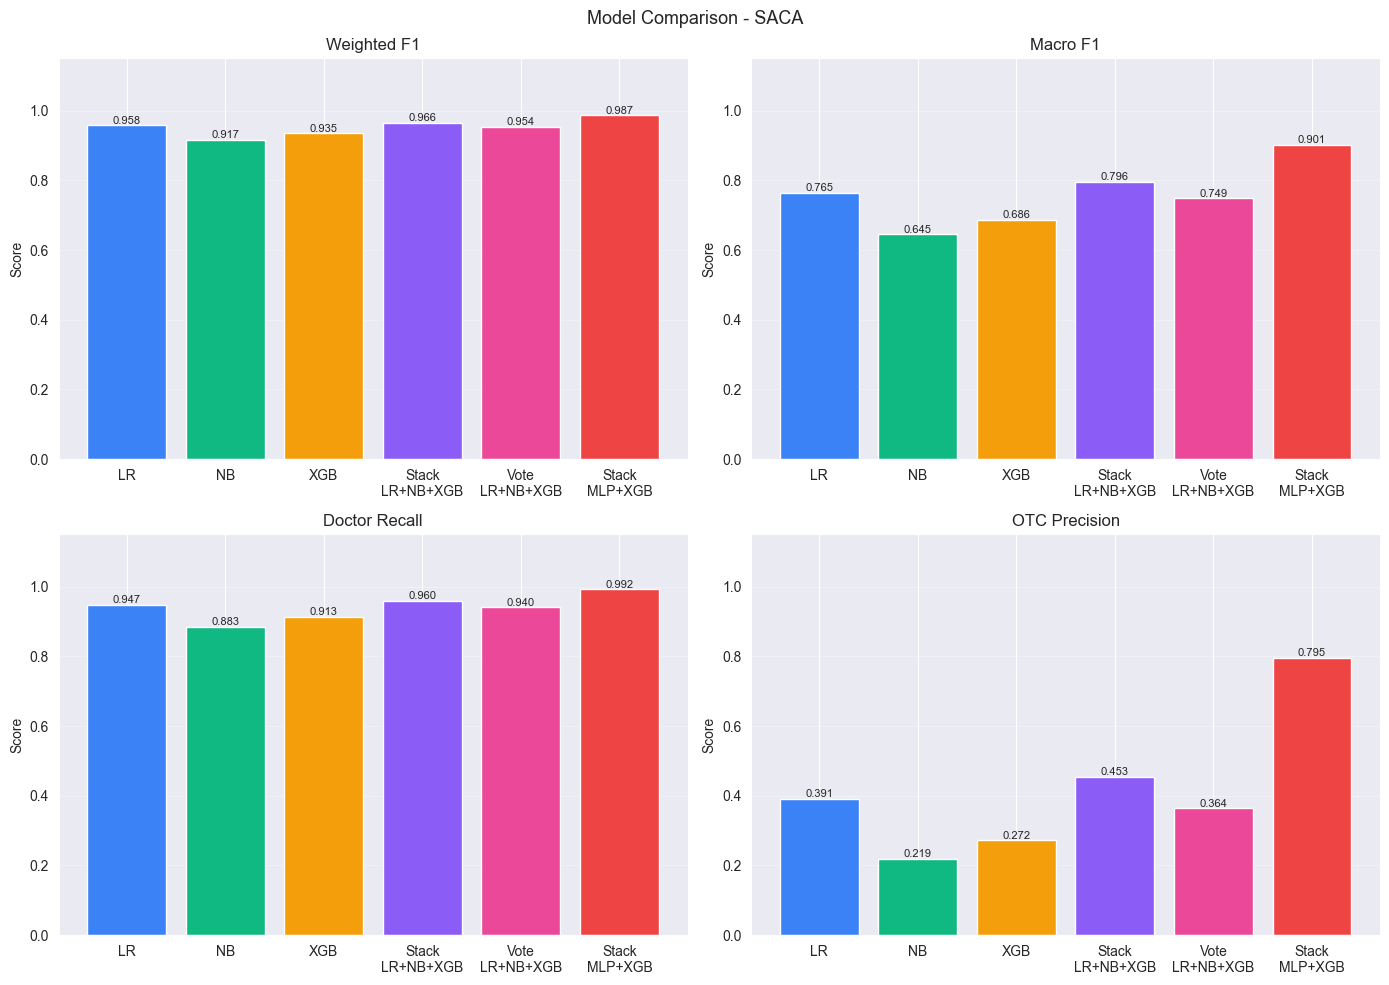

In [24]:
# metric comparison bar charts
metrics = ['weighted_f1', 'macro_f1', 'doctor_recall', 'otc_precision']
metric_labels = ['Weighted F1', 'Macro F1', 'Doctor Recall', 'OTC Precision']
short_names = ['LR', 'NB', 'XGB', 'Stack\nLR+NB+XGB', 'Vote\nLR+NB+XGB', 'Stack\nMLP+XGB']
colors = ['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6', '#EC4899', '#EF4444']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison - SACA', fontsize=13)

for ax, metric, label in zip(axes.flatten(), metrics, metric_labels):
    values = [results[name][metric] for name in models]
    bars = ax.bar(short_names, values, color=colors, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)
    ax.set_title(label)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

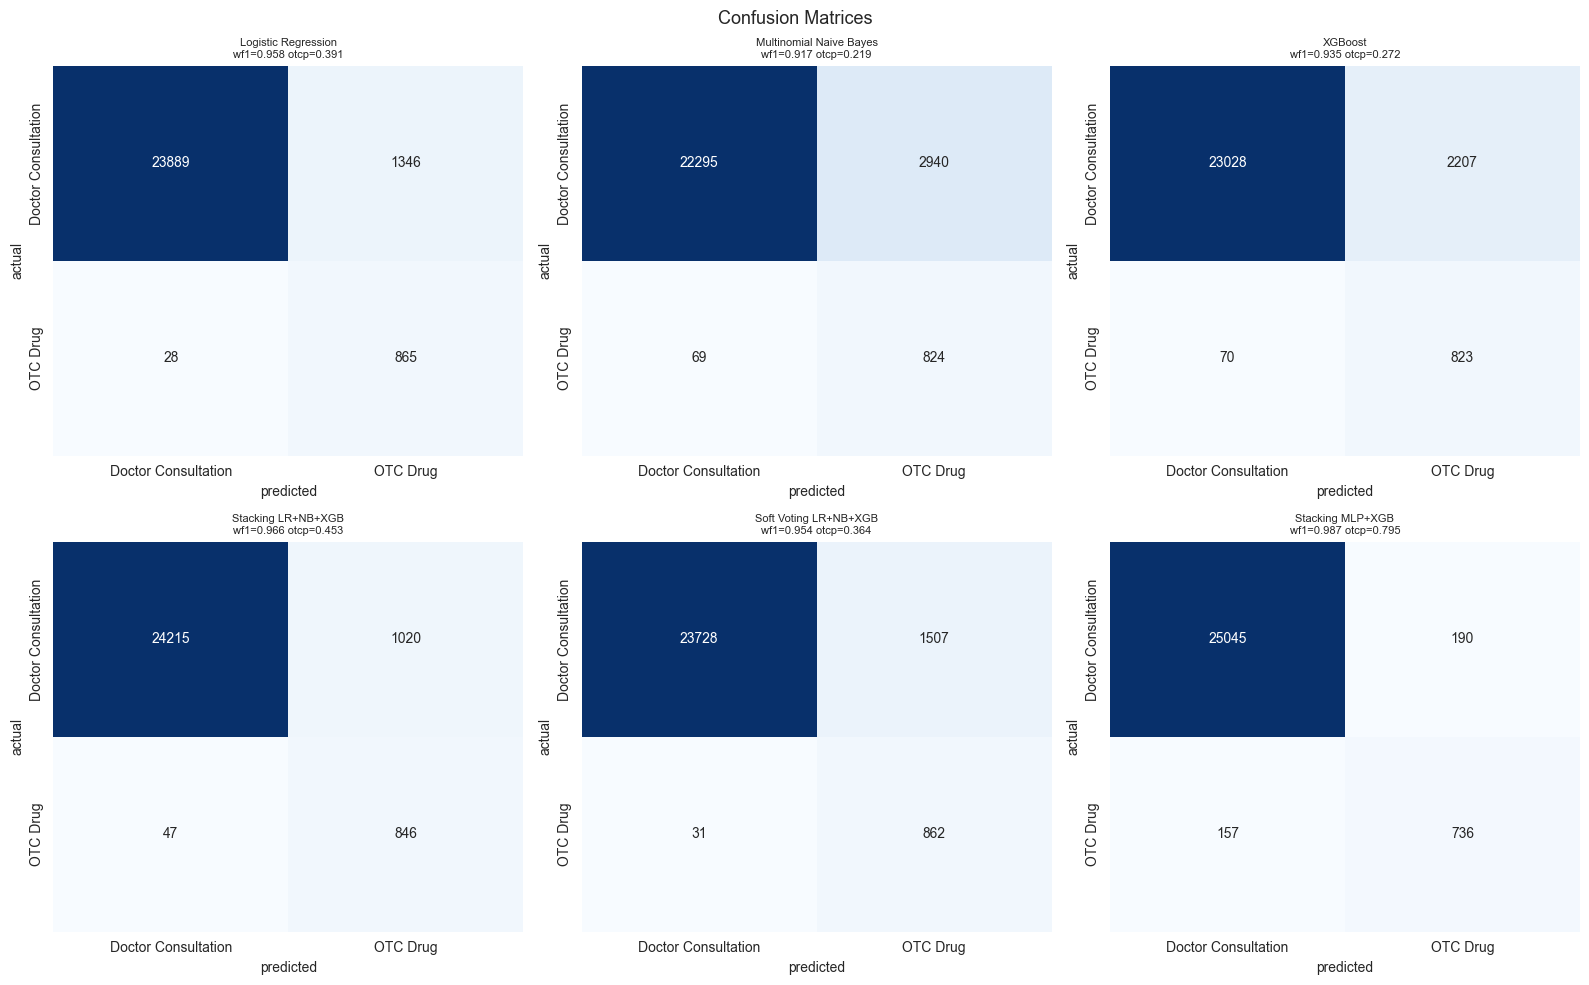

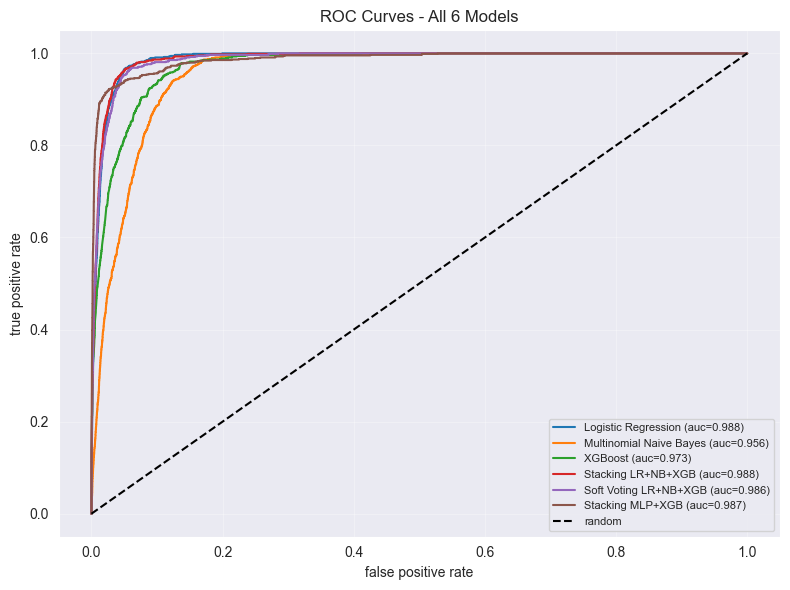


done
best model: Stacking MLP+XGB
models saved to ../models/


In [25]:
# confusion matrices for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices', fontsize=13)

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nwf1={res['weighted_f1']:.3f} otcp={res['otc_precision']:.3f}",
                 fontsize=8)
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    if res['auc']:
        y_proba = res['model'].predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        ax.plot(fpr, tpr, label=f"{name} (auc={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='random')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC Curves - All 6 Models')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\ndone")
print(f"best model: {best['name']}")
print("models saved to ../models/")